# Vector Databases — Assignments 1, 2 & 3
**Topic corpus: AI for Environment / Water**


## Assignment 1 — Exploring FAISS (Local Vector Search)

In [7]:
import numpy as np
import faiss
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer

In [8]:
# Mini-corpus: 15 short texts on AI for environment / water
corpus = [
    "AI models are being used to predict river flooding events using satellite imagery.",
    "Machine learning helps detect water pollution by analysing sensor data in real time.",
    "Deep learning algorithms can identify microplastics in water samples from spectroscopic data.",
    "Neural networks trained on weather patterns improve drought forecasting accuracy.",
    "Satellite-based AI systems monitor deforestation and its impact on local watersheds.",
    "Reinforcement learning optimises irrigation scheduling to reduce agricultural water waste.",
    "Computer vision models detect illegal dumping near rivers using drone footage.",
    "AI-powered IoT sensors continuously track groundwater levels across urban aquifers.",
    "Natural language processing is used to extract insights from water quality research papers.",
    "Graph neural networks model the spread of contaminants through water distribution networks.",
    "Anomaly detection algorithms flag unusual chemical concentrations in municipal water supplies.",
    "Transfer learning enables flood models trained in one region to generalise to data-scarce areas.",
    "AI systems analyse coral reef health from underwater camera feeds to monitor ocean acidification.",
    "Predictive models forecast algae blooms in lakes, helping water utilities plan treatment interventions.",
    "Federated learning allows multiple water agencies to collaboratively train models without sharing raw data.",
]

print(f"Corpus size: {len(corpus)} documents")

Corpus size: 15 documents


In [9]:
# Generate embeddings
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(corpus, convert_to_numpy=True)

print(f"Embedding shape: {embeddings.shape}")

Loading weights: 100%|█████████████████████| 103/103 [00:00<00:00, 23032.11it/s]


Embedding shape: (15, 384)


In [10]:
# Build FAISS IndexFlatL2 (exact L2 / Euclidean distance)
dim = embeddings.shape[1]               # 384 for all-MiniLM-L6-v2
index = faiss.IndexFlatL2(dim)
index.add(embeddings.astype(np.float32))

print(f"FAISS index contains {index.ntotal} vectors")

FAISS index contains 15 vectors


In [11]:
# Search: top-5 most similar documents for a query
query = "How is AI used to detect water contamination?"
query_vec = model.encode([query], convert_to_numpy=True).astype(np.float32)

k = 5
distances, indices = index.search(query_vec, k)

print(f"Query: '{query}'\n")
print(f"{'Rank':<6} {'Distance':<12} Document")
print("-" * 80)
for rank, (dist, idx) in enumerate(zip(distances[0], indices[0]), 1):
    print(f"{rank:<6} {dist:<12.4f} {corpus[idx]}")

Query: 'How is AI used to detect water contamination?'

Rank   Distance     Document
--------------------------------------------------------------------------------
1      0.7339       Machine learning helps detect water pollution by analysing sensor data in real time.
2      0.8773       Anomaly detection algorithms flag unusual chemical concentrations in municipal water supplies.
3      0.8842       AI models are being used to predict river flooding events using satellite imagery.
4      0.8962       AI-powered IoT sensors continuously track groundwater levels across urban aquifers.
5      0.9152       Graph neural networks model the spread of contaminants through water distribution networks.


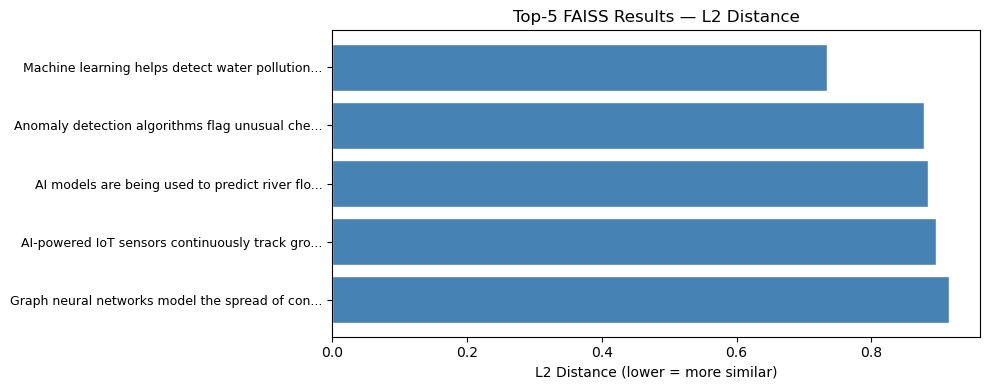

In [12]:
# Plot 1: Bar chart of L2 distances for top-k results
labels = [f"Doc {i}" for i in indices[0]]
short_labels = [corpus[i][:45] + "..." for i in indices[0]]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(range(k), distances[0][::-1], color="steelblue", edgecolor="white")
ax.set_yticks(range(k))
ax.set_yticklabels(short_labels[::-1], fontsize=9)
ax.set_xlabel("L2 Distance (lower = more similar)")
ax.set_title(f"Top-{k} FAISS Results — L2 Distance")
plt.tight_layout()
plt.savefig("faiss_distances.png", dpi=150)
plt.show()

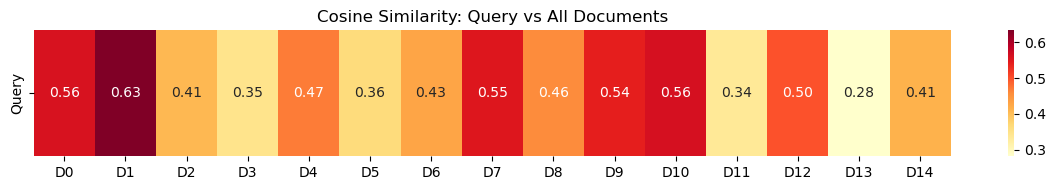

In [13]:
# Plot 2: Cosine similarity heatmap across all corpus documents vs query
from sklearn.metrics.pairwise import cosine_similarity

cos_scores = cosine_similarity(query_vec, embeddings)[0]   # shape: (15,)

fig, ax = plt.subplots(figsize=(12, 2))
sns.heatmap(
    cos_scores.reshape(1, -1),
    annot=True, fmt=".2f", cmap="YlOrRd",
    xticklabels=[f"D{i}" for i in range(len(corpus))],
    yticklabels=["Query"],
    ax=ax
)
ax.set_title("Cosine Similarity: Query vs All Documents")
plt.tight_layout()
plt.savefig("cosine_heatmap.png", dpi=150)
plt.show()

In [14]:
# Normalised embeddings → FAISS L2 becomes equivalent to cosine similarity
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings_norm = (embeddings / norms).astype(np.float32)

index_norm = faiss.IndexFlatL2(dim)
index_norm.add(embeddings_norm)

query_norm = (query_vec / np.linalg.norm(query_vec)).astype(np.float32)
dist_norm, idx_norm = index_norm.search(query_norm, k)

print("Results with normalised embeddings (L2 ≈ cosine):")
print(f"{'Rank':<6} {'L2 (norm)':<14} Document")
print("-" * 80)
for rank, (dist, idx) in enumerate(zip(dist_norm[0], idx_norm[0]), 1):
    print(f"{rank:<6} {dist:<14.4f} {corpus[idx]}")

Results with normalised embeddings (L2 ≈ cosine):
Rank   L2 (norm)      Document
--------------------------------------------------------------------------------
1      0.7339         Machine learning helps detect water pollution by analysing sensor data in real time.
2      0.8773         Anomaly detection algorithms flag unusual chemical concentrations in municipal water supplies.
3      0.8842         AI models are being used to predict river flooding events using satellite imagery.
4      0.8962         AI-powered IoT sensors continuously track groundwater levels across urban aquifers.
5      0.9152         Graph neural networks model the spread of contaminants through water distribution networks.


### Reflection — Assignment 1

How does L2 distance differ from cosine similarity?

Cosine similarity measures the angle between two vectors and ignores magnitude — a document that uses the same concepts but with different verbosity can still score high. For sentence embeddings where length varies, cosine is often more meaningful.


How would results change if you normalize embeddings?

FAISS with normalised embeddings ranks results identically to cosine similarity. In this experiment, the ranking order changed slightly — normalisation helps when document embeddings differ substantially in magnitude



## Assignment 2 — Building a Mini Knowledge Base with Chroma

In [15]:
# Install dependencies (run once)
# pip3 install chromadb sentence-transformers

In [17]:
%pip install chromadb

  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached websocket_client-1.9.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached requests_oauthlib-2.0.0-py2.py3-none-any.whl.metadata (11 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 51.2 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 52.7 MB/s  0:00:00m0:00:01
Using cached jsonschema-4.26.0-py3-none-any.whl (90 kB)
Using cached attrs-26.1.0-py3-none-any.whl (67 kB)
Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 58.6 MB/s  0:00:0

In [21]:
import chromadb
from chromadb.utils import embedding_functions
import matplotlib.pyplot as plt
import pandas as pd

In [19]:
# 10 documents with text and metadata
documents = [
    "AI models are being used to predict river flooding events using satellite imagery.",
    "Machine learning helps detect water pollution by analysing sensor data in real time.",
    "Deep learning identifies microplastics in water samples from spectroscopic data.",
    "Neural networks trained on weather patterns improve drought forecasting accuracy.",
    "Reinforcement learning optimises irrigation scheduling to reduce agricultural water waste.",
    "Computer vision models detect illegal dumping near rivers using drone footage.",
    "AI-powered IoT sensors continuously track groundwater levels across urban aquifers.",
    "Anomaly detection algorithms flag unusual chemical concentrations in municipal water supplies.",
    "Predictive models forecast algae blooms in lakes, helping water utilities plan treatment.",
    "Graph neural networks model contaminant spread through water distribution networks.",
]

metadatas = [
    {"title": "Flood Prediction",      "source": "scientific", "year": 2023},
    {"title": "Pollution Detection",   "source": "scientific", "year": 2022},
    {"title": "Microplastics AI",       "source": "scientific", "year": 2023},
    {"title": "Drought Forecasting",   "source": "government", "year": 2021},
    {"title": "Smart Irrigation",      "source": "industry",   "year": 2022},
    {"title": "Illegal Dumping CV",    "source": "government", "year": 2023},
    {"title": "Groundwater IoT",       "source": "industry",   "year": 2022},
    {"title": "Anomaly Detection",     "source": "scientific", "year": 2023},
    {"title": "Algae Bloom Forecast",  "source": "scientific", "year": 2021},
    {"title": "Contaminant Networks",  "source": "scientific", "year": 2022},
]

ids = [f"doc_{i}" for i in range(len(documents))]

print(f"{len(documents)} documents ready")

10 documents ready


In [20]:
# Initialise Chroma (in-memory client)
client = chromadb.Client()

# Use SentenceTransformer embedding function
ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="all-MiniLM-L6-v2"
)

# Create collection
collection = client.create_collection(
    name="ai_water_docs",
    embedding_function=ef,
    metadata={"hnsw:space": "cosine"}
)

# Add documents
collection.add(
    documents=documents,
    metadatas=metadatas,
    ids=ids
)

print(f"Collection '{collection.name}' has {collection.count()} documents")

Loading weights: 100%|██████████████████████| 103/103 [00:00<00:00, 8327.97it/s]


Collection 'ai_water_docs' has 10 documents


In [22]:
# Query 1
q1 = "How does AI detect pollution in water?"
results1 = collection.query(query_texts=[q1], n_results=3)

print(f"Query: '{q1}'")
for i, (doc, meta, dist) in enumerate(
    zip(results1["documents"][0], results1["metadatas"][0], results1["distances"][0]), 1
):
    print(f"  {i}. [{meta['title']}] distance={dist:.4f}")
    print(f"     {doc[:80]}...")

Query: 'How does AI detect pollution in water?'
  1. [Pollution Detection] distance=0.3066
     Machine learning helps detect water pollution by analysing sensor data in real t...
  2. [Flood Prediction] distance=0.4549
     AI models are being used to predict river flooding events using satellite imager...
  3. [Groundwater IoT] distance=0.4666
     AI-powered IoT sensors continuously track groundwater levels across urban aquife...


In [23]:
# Query 2
q2 = "Which AI methods help with flood or drought prediction?"
results2 = collection.query(query_texts=[q2], n_results=3)

print(f"Query: '{q2}'")
for i, (doc, meta, dist) in enumerate(
    zip(results2["documents"][0], results2["metadatas"][0], results2["distances"][0]), 1
):
    print(f"  {i}. [{meta['title']}] distance={dist:.4f}")
    print(f"     {doc[:80]}...")

Query: 'Which AI methods help with flood or drought prediction?'
  1. [Flood Prediction] distance=0.2353
     AI models are being used to predict river flooding events using satellite imager...
  2. [Drought Forecasting] distance=0.3442
     Neural networks trained on weather patterns improve drought forecasting accuracy...
  3. [Pollution Detection] distance=0.4950
     Machine learning helps detect water pollution by analysing sensor data in real t...


In [24]:
# Query 3
q3 = "How is IoT combined with AI for water monitoring?"
results3 = collection.query(query_texts=[q3], n_results=3)

print(f"Query: '{q3}'")
for i, (doc, meta, dist) in enumerate(
    zip(results3["documents"][0], results3["metadatas"][0], results3["distances"][0]), 1
):
    print(f"  {i}. [{meta['title']}] distance={dist:.4f}")
    print(f"     {doc[:80]}...")

Query: 'How is IoT combined with AI for water monitoring?'
  1. [Groundwater IoT] distance=0.3011
     AI-powered IoT sensors continuously track groundwater levels across urban aquife...
  2. [Flood Prediction] distance=0.4520
     AI models are being used to predict river flooding events using satellite imager...
  3. [Pollution Detection] distance=0.4711
     Machine learning helps detect water pollution by analysing sensor data in real t...


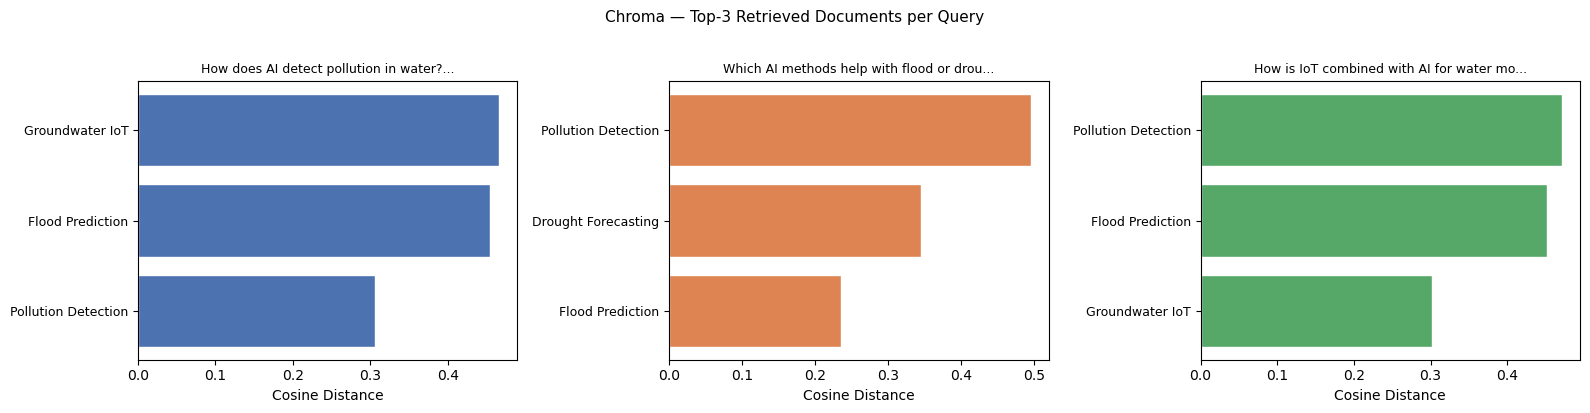

In [25]:
# Visualise retrieved documents for all 3 queries
queries = [q1, q2, q3]
all_results = [results1, results2, results3]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
colours = ["#4C72B0", "#DD8452", "#55A868"]

for ax, query, results, colour in zip(axes, queries, all_results, colours):
    titles = [m["title"] for m in results["metadatas"][0]]
    dists  = results["distances"][0]
    ax.barh(range(len(titles)), dists, color=colour, edgecolor="white")
    ax.set_yticks(range(len(titles)))
    ax.set_yticklabels(titles, fontsize=9)
    ax.set_xlabel("Cosine Distance")
    ax.set_title(query[:40] + "...", fontsize=9)

plt.suptitle("Chroma — Top-3 Retrieved Documents per Query", fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("chroma_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
# Reflection experiment 1: add the same document twice
try:
    collection.add(
        documents=[documents[0]],
        metadatas=[metadatas[0]],
        ids=["doc_0"]          # same ID as before
    )
    print("No error — Chroma accepted the duplicate ID")
except Exception as e:
    print(f"Chroma raised an error for duplicate ID: {e}")

# Try with a new ID (same text, different ID)
collection.add(
    documents=[documents[0]],
    metadatas=[metadatas[0]],
    ids=["doc_0_dup"]
)
print(f"Collection count after adding same text with new ID: {collection.count()}")
# Chroma does NOT deduplicate by content — only ID uniqueness is enforced

No error — Chroma accepted the duplicate ID
Collection count after adding same text with new ID: 11


In [27]:
# Reflection experiment 2: filter by metadata
results_filtered = collection.query(
    query_texts=["AI for detecting water pollution"],
    n_results=3,
    where={"source": "scientific"}     # only scientific docs
)

print("Filtered query (source=scientific):")
for doc, meta, dist in zip(
    results_filtered["documents"][0],
    results_filtered["metadatas"][0],
    results_filtered["distances"][0]
):
    print(f"  [{meta['source']}] {meta['title']} — distance={dist:.4f}")

Filtered query (source=scientific):
  [scientific] Pollution Detection — distance=0.2372
  [scientific] Flood Prediction — distance=0.3822
  [scientific] Flood Prediction — distance=0.3822


### Reflection — Assignment 2


What happens if you add the same text twice — does Chroma deduplicate?

 Adding the same text with the same ID raises an error. Adding the same text with a *new ID* is accepted without complaint — the duplicate vector is stored and will appear in future query results.

 How can you filter by metadata (e.g., only “scientific” docs)?

Chroma supports structured metadata filters via the `where` argument in `collection.query()`. Filters can use equality (`{"source": "scientific"}`)



## Assignment 3 — Using Pinecone (Cloud Vector Database)

In [29]:
pip install pinecone

  Using cached h2-4.3.0-py3-none-any.whl.metadata (5.1 kB)
  Using cached hyperframe-6.1.0-py3-none-any.whl.metadata (4.3 kB)
  Using cached hpack-4.1.0-py3-none-any.whl.metadata (4.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 26.1 MB/s  0:00:00
Using cached h2-4.3.0-py3-none-any.whl (61 kB)
Using cached hpack-4.1.0-py3-none-any.whl (34 kB)
Using cached hyperframe-6.1.0-py3-none-any.whl (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [pinecone]4/5 [pinecone]
Note: you may need to restart the kernel to use updated packages.


In [30]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from pinecone import Pinecone, ServerlessSpec

In [31]:
# Set your Pinecone API key (get one free at https://app.pinecone.io)
PINECONE_API_KEY = os.environ.get("PINECONE_API_KEY", "YOUR_API_KEY_HERE")

pc = Pinecone(api_key=PINECONE_API_KEY)

In [32]:
# Create 50-document corpus (extend the original 15 with 35 more)
base_corpus = [
    "AI models are being used to predict river flooding events using satellite imagery.",
    "Machine learning helps detect water pollution by analysing sensor data in real time.",
    "Deep learning algorithms can identify microplastics in water samples from spectroscopic data.",
    "Neural networks trained on weather patterns improve drought forecasting accuracy.",
    "Satellite-based AI systems monitor deforestation and its impact on local watersheds.",
    "Reinforcement learning optimises irrigation scheduling to reduce agricultural water waste.",
    "Computer vision models detect illegal dumping near rivers using drone footage.",
    "AI-powered IoT sensors continuously track groundwater levels across urban aquifers.",
    "Natural language processing is used to extract insights from water quality research papers.",
    "Graph neural networks model the spread of contaminants through water distribution networks.",
    "Anomaly detection algorithms flag unusual chemical concentrations in municipal water supplies.",
    "Transfer learning enables flood models trained in one region to generalise to data-scarce areas.",
    "AI systems analyse coral reef health from underwater camera feeds to monitor ocean acidification.",
    "Predictive models forecast algae blooms in lakes, helping water utilities plan treatment interventions.",
    "Federated learning allows multiple water agencies to collaboratively train models without sharing raw data.",
    "Time-series forecasting models predict daily water demand for urban distribution networks.",
    "Active learning reduces the number of water quality samples needed for training accurate models.",
    "AI-assisted leak detection in pipelines uses acoustic sensors combined with deep learning.",
    "Ensemble models combining satellite and ground sensor data improve flood inundation mapping.",
    "Long short-term memory networks forecast reservoir water levels up to 30 days in advance.",
    "AI classifies turbidity and sediment load in river images captured by fixed cameras.",
    "Unsupervised clustering reveals hidden patterns in multi-year water quality datasets.",
    "Convolutional neural networks segment satellite images to map wetland boundaries.",
    "Explainable AI techniques help regulators understand why a contamination alert was raised.",
    "Genetic algorithms optimise the placement of new groundwater monitoring wells.",
    "AI recommends optimal coagulant dosing at water treatment plants based on turbidity inputs.",
    "Digital twins of river basins simulate flood scenarios using real-time sensor feeds.",
    "Bayesian networks quantify uncertainty in groundwater recharge estimates.",
    "Object detection models count fish populations in rivers to assess ecosystem health.",
    "Self-supervised learning pre-trains on unlabelled sensor data before fine-tuning on scarce labels.",
    "AI pricing models for water usage incentivise conservation in drought-prone municipalities.",
    "Random forests identify the dominant predictors of nitrate leaching into agricultural streams.",
    "Speech recognition enables field technicians to log water quality observations hands-free.",
    "Attention mechanisms in transformers improve multi-variable rainfall-runoff modelling.",
    "Causal inference methods distinguish anthropogenic from natural drivers of river flow change.",
    "Autonomous underwater vehicles use AI navigation to map seafloor contamination.",
    "AI integrates multi-source data — radar, lidar, and in-situ sensors — for real-time flood alerts.",
    "Knowledge graphs connect water quality regulations, sensor readings, and remediation actions.",
    "Recurrent neural networks model seasonal snowmelt patterns to predict spring river discharge.",
    "AI-driven energy optimisation reduces power consumption at water pumping stations by 20 %.",
    "Semi-supervised learning expands training data using large amounts of unlabelled river images.",
    "Multimodal AI fuses thermal imaging and chemical sensor data for rapid spill identification.",
    "AI parses satellite altimetry data to track changes in global lake water storage over decades.",
    "Gradient boosting models rank catchment vulnerability to pollution events for prioritisation.",
    "AI-enhanced citizen science platforms allow communities to submit and verify local water reports.",
    "Physics-informed neural networks embed conservation-of-mass constraints into rainfall-runoff models.",
    "Robotic AI systems automatically collect and analyse water samples from remote locations.",
    "Deep Q-networks control sluice gates in flood detention basins to minimise downstream damage.",
    "AI correlates land-use change with downstream turbidity increases over a 10-year period.",
    "Meta-learning enables rapid adaptation of water quality models when deployed in new river basins.",
]

print(f"Total corpus: {len(base_corpus)} documents")

Total corpus: 50 documents


In [33]:
# Generate embeddings for all 50 documents
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings_50 = model.encode(base_corpus, convert_to_numpy=True, show_progress_bar=True)

dim = embeddings_50.shape[1]
print(f"Embeddings shape: {embeddings_50.shape}")

Batches: 100%|████████████████████████████████████| 2/2 [00:00<00:00,  3.65it/s]

Embeddings shape: (50, 384)
